In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256, 256)),
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

# Brain Tumor Classifier using PyTorch

- classifies MRI scans as glioma, meningioma, pituitary, or no tumor  
- uses a small cnn with a few conv and dense layers  
- trains on 256x256 grayscale images from images/Training and images/Testing  
- tracks training and validation accuracy each epoch  
- includes a quick test function to predict any single image and show its confidence


In [2]:
train_dataset = datasets.ImageFolder(root="images/Training", transform=transform)
test_dataset = datasets.ImageFolder(root="images/Testing", transform=transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)
print("Number of training samples:", len(train_dataset))
print("Number of testing samples:", len(test_dataset))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training samples: 5712
Number of testing samples: 1311


In [3]:
# Original CNN Model
class BrainTumorCNN(nn.Module):
    def __init__(self):
        super(BrainTumorCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, 4)  # 4 output classes

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1, 64 * 32 * 32)  # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
# Training function
def train_brain_tumor_model(model, train_loader, test_loader, criterion, optimizer, epochs=10):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

        avg_train_loss = total_loss / len(train_loader.dataset)
        train_acc = 100 * correct / len(train_loader.dataset)

        # Evaluate
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()

        avg_val_loss = val_loss / len(test_loader.dataset)
        val_acc = 100 * val_correct / len(test_loader.dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return train_losses, val_losses, train_accs, val_accs

In [5]:
# Hyperparameters
EPOCHS = 10
LR = 0.001
BATCH_SIZE = 32
EVAL_EVERY = 1

criterion = nn.CrossEntropyLoss()
model = BrainTumorCNN()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [6]:
# Train Model(may take a while) - adjust hyperparameters first - see above
train_losses, val_losses, train_accs, val_accs = train_brain_tumor_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=EPOCHS
)

torch.save(model.state_dict(), "brain_tumor_cnn.pth")


Epoch 1/10 | Train Loss: 0.6517 | Train Acc: 74.35% | Val Loss: 0.5732 | Val Acc: 76.58%
Epoch 2/10 | Train Loss: 0.3247 | Train Acc: 87.68% | Val Loss: 0.3779 | Val Acc: 86.65%
Epoch 2/10 | Train Loss: 0.3247 | Train Acc: 87.68% | Val Loss: 0.3779 | Val Acc: 86.65%
Epoch 3/10 | Train Loss: 0.1919 | Train Acc: 93.26% | Val Loss: 0.2833 | Val Acc: 89.63%
Epoch 3/10 | Train Loss: 0.1919 | Train Acc: 93.26% | Val Loss: 0.2833 | Val Acc: 89.63%
Epoch 4/10 | Train Loss: 0.1131 | Train Acc: 96.15% | Val Loss: 0.2105 | Val Acc: 93.29%
Epoch 4/10 | Train Loss: 0.1131 | Train Acc: 96.15% | Val Loss: 0.2105 | Val Acc: 93.29%
Epoch 5/10 | Train Loss: 0.0635 | Train Acc: 97.90% | Val Loss: 0.1891 | Val Acc: 94.05%
Epoch 5/10 | Train Loss: 0.0635 | Train Acc: 97.90% | Val Loss: 0.1891 | Val Acc: 94.05%
Epoch 6/10 | Train Loss: 0.0535 | Train Acc: 98.30% | Val Loss: 0.2109 | Val Acc: 93.21%
Epoch 6/10 | Train Loss: 0.0535 | Train Acc: 98.30% | Val Loss: 0.2109 | Val Acc: 93.21%
Epoch 7/10 | Train Lo

## Experiment 1: Original CNN with Different Learning Rates

Testing the original CNN architecture with:
- Learning Rate 1: 0.001 (original) with 10 epochs
- Learning Rate 2: 0.005 with 20 epochs  
- Learning Rate 3: 0.01 with 20 epochs

This will help us understand the impact of learning rate on convergence and performance.

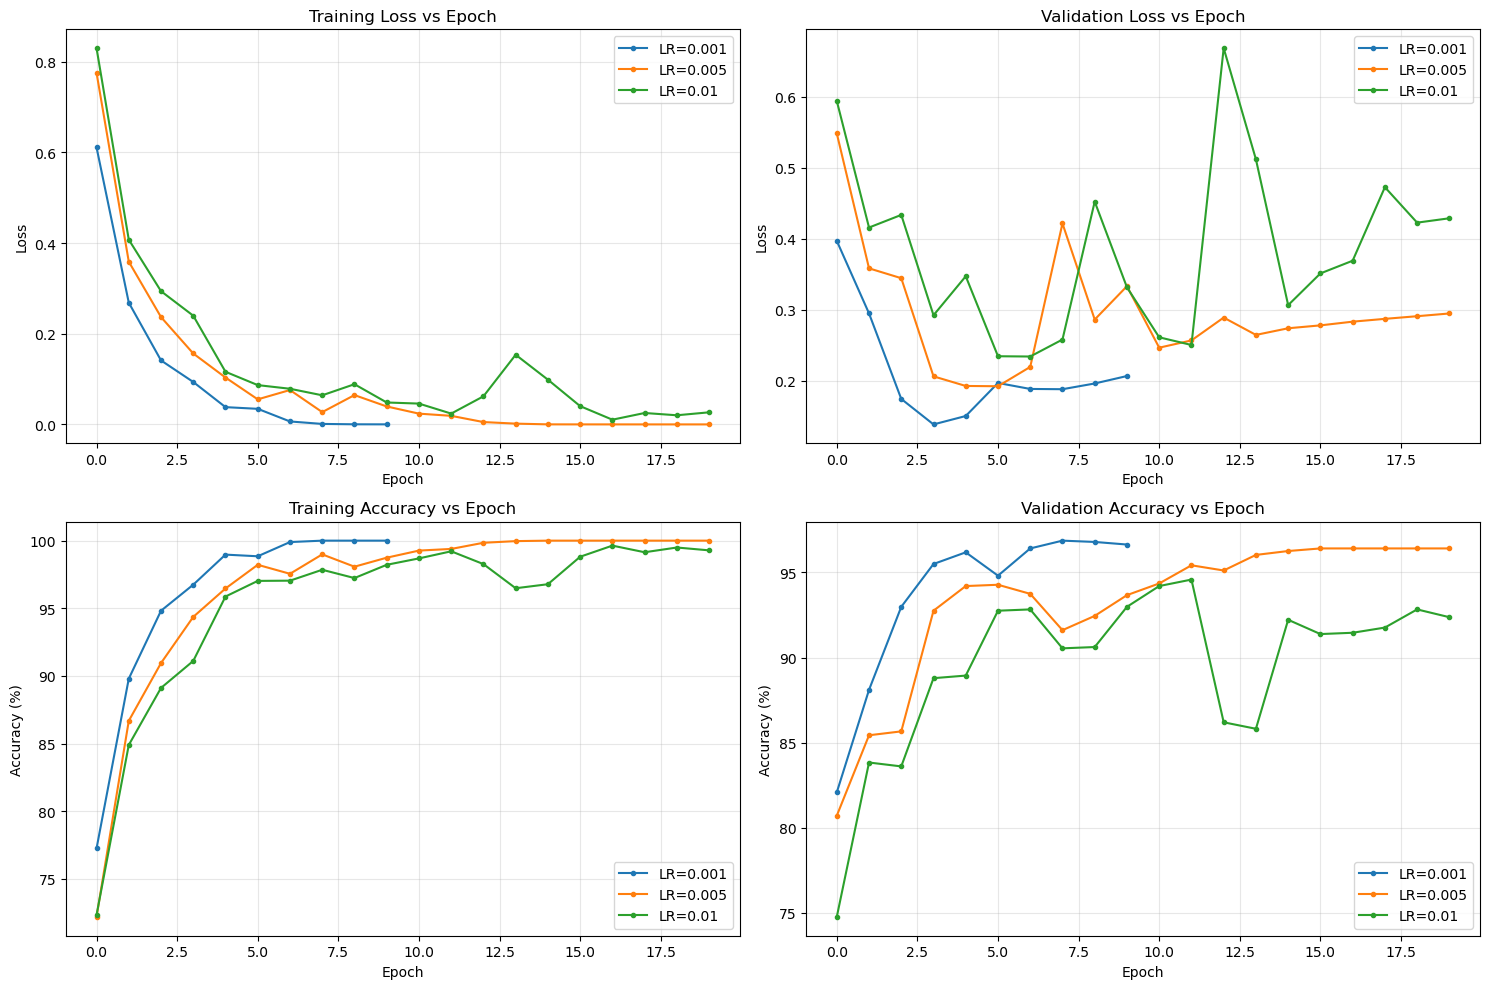


SUMMARY: CNN with Different Learning Rates

LR=0.001:
  Final Train Acc: 100.00%
  Final Val Acc: 96.64%
  Best Val Acc: 96.87% (Epoch 8)

LR=0.005:
  Final Train Acc: 100.00%
  Final Val Acc: 96.41%
  Best Val Acc: 96.41% (Epoch 16)

LR=0.01:
  Final Train Acc: 99.28%
  Final Val Acc: 92.37%
  Best Val Acc: 94.58% (Epoch 12)


In [8]:
# Plot comparison of different learning rates for CNN
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training Loss
for lr in learning_rates:
    axes[0, 0].plot(results_cnn[lr]['train_losses'], label=f'LR={lr}', marker='o', markersize=3)
axes[0, 0].set_title('Training Loss vs Epoch')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
for lr in learning_rates:
    axes[0, 1].plot(results_cnn[lr]['val_losses'], label=f'LR={lr}', marker='o', markersize=3)
axes[0, 1].set_title('Validation Loss vs Epoch')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy
for lr in learning_rates:
    axes[1, 0].plot(results_cnn[lr]['train_accs'], label=f'LR={lr}', marker='o', markersize=3)
axes[1, 0].set_title('Training Accuracy vs Epoch')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
for lr in learning_rates:
    axes[1, 1].plot(results_cnn[lr]['val_accs'], label=f'LR={lr}', marker='o', markersize=3)
axes[1, 1].set_title('Validation Accuracy vs Epoch')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("SUMMARY: CNN with Different Learning Rates")
print("="*60)
for lr in learning_rates:
    print(f"\nLR={lr}:")
    print(f"  Final Train Acc: {results_cnn[lr]['train_accs'][-1]:.2f}%")
    print(f"  Final Val Acc: {results_cnn[lr]['val_accs'][-1]:.2f}%")
    print(f"  Best Val Acc: {max(results_cnn[lr]['val_accs']):.2f}% (Epoch {results_cnn[lr]['val_accs'].index(max(results_cnn[lr]['val_accs']))+1})")

## Experiment 2: ResNet18 Implementation

ResNet18 with transfer learning:
- Pre-trained on ImageNet
- Modified for grayscale input (1 channel)
- Modified for 4-class output
- Uses skip connections for better gradient flow

In [9]:
# ResNet18 Model
def create_resnet18(num_classes=4, pretrained=True):
    """
    Create ResNet18 model adapted for grayscale images
    """
    model = models.resnet18(pretrained=pretrained)
    
    # Modify first conv layer for grayscale (1 channel) instead of RGB (3 channels)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    
    # Modify final fully connected layer for 4 classes
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

# Train ResNet18
print("="*60)
print("Training ResNet18")
print("="*60)

model_resnet = create_resnet18(num_classes=4, pretrained=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=0.001)

train_losses_resnet, val_losses_resnet, train_accs_resnet, val_accs_resnet = train_brain_tumor_model(
    model_resnet, train_loader, test_loader, criterion, optimizer, epochs=20
)

# Save model
torch.save(model_resnet.state_dict(), "brain_tumor_resnet18.pth")

print(f"\nFinal ResNet18 Results:")
print(f"  Train Acc: {train_accs_resnet[-1]:.2f}% | Val Acc: {val_accs_resnet[-1]:.2f}%")
print(f"  Train Loss: {train_losses_resnet[-1]:.4f} | Val Loss: {val_losses_resnet[-1]:.4f}")

Training ResNet18


/opt/homebrew/Caskroom/miniconda/base/envs/CS-3600/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/CS-3600/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 | Train Loss: 0.3860 | Train Acc: 86.38% | Val Loss: 0.3935 | Val Acc: 84.97%
Epoch 2/20 | Train Loss: 0.2115 | Train Acc: 92.09% | Val Loss: 0.3210 | Val Acc: 87.49%
Epoch 2/20 | Train Loss: 0.2115 | Train Acc: 92.09% | Val Loss: 0.3210 | Val Acc: 87.49%
Epoch 3/20 | Train Loss: 0.1419 | Train Acc: 95.06% | Val Loss: 0.1788 | Val Acc: 93.14%
Epoch 3/20 | Train Loss: 0.1419 | Train Acc: 95.06% | Val Loss: 0.1788 | Val Acc: 93.14%
Epoch 4/20 | Train Loss: 0.0832 | Train Acc: 97.27% | Val Loss: 0.1696 | Val Acc: 93.75%
Epoch 4/20 | Train Loss: 0.0832 | Train Acc: 97.27% | Val Loss: 0.1696 | Val Acc: 93.75%
Epoch 5/20 | Train Loss: 0.0741 | Train Acc: 97.30% | Val Loss: 0.0863 | Val Acc: 97.64%
Epoch 5/20 | Train Loss: 0.0741 | Train Acc: 97.30% | Val Loss: 0.0863 | Val Acc: 97.64%
Epoch 6/20 | Train Loss: 0.0668 | Train Acc: 97.90% | Val Loss: 0.1082 | Val Acc: 95.80%
Epoch 6/20 | Train Loss: 0.0668 | Train Acc: 97.90% | Val Loss: 0.1082 | Val Acc: 95.80%
Epoch 7/20 | Train Lo

## Experiment 3: EfficientNet-B0 Implementation

EfficientNet-B0 with transfer learning:
- Pre-trained on ImageNet
- Compound scaling of depth, width, and resolution
- Modified for grayscale input (1 channel)
- Modified for 4-class output

In [10]:
# EfficientNet-B0 Model
def create_efficientnet_b0(num_classes=4, pretrained=True):
    """
    Create EfficientNet-B0 model adapted for grayscale images
    """
    model = models.efficientnet_b0(pretrained=pretrained)
    
    # Modify first conv layer for grayscale (1 channel)
    # EfficientNet has features[0][0] as the first conv layer
    model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
    
    # Modify final classifier for 4 classes
    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_features, num_classes)
    
    return model

# Train EfficientNet-B0
print("="*60)
print("Training EfficientNet-B0")
print("="*60)

model_effnet = create_efficientnet_b0(num_classes=4, pretrained=True)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_effnet.parameters(), lr=0.001)

train_losses_effnet, val_losses_effnet, train_accs_effnet, val_accs_effnet = train_brain_tumor_model(
    model_effnet, train_loader, test_loader, criterion, optimizer, epochs=20
)

# Save model
torch.save(model_effnet.state_dict(), "brain_tumor_efficientnet_b0.pth")

print(f"\nFinal EfficientNet-B0 Results:")
print(f"  Train Acc: {train_accs_effnet[-1]:.2f}% | Val Acc: {val_accs_effnet[-1]:.2f}%")
print(f"  Train Loss: {train_losses_effnet[-1]:.4f} | Val Loss: {val_losses_effnet[-1]:.4f}")

Training EfficientNet-B0


/opt/homebrew/Caskroom/miniconda/base/envs/CS-3600/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20 | Train Loss: 0.2933 | Train Acc: 89.88% | Val Loss: 0.1255 | Val Acc: 95.96%
Epoch 2/20 | Train Loss: 0.1421 | Train Acc: 95.22% | Val Loss: 0.1713 | Val Acc: 93.82%
Epoch 2/20 | Train Loss: 0.1421 | Train Acc: 95.22% | Val Loss: 0.1713 | Val Acc: 93.82%
Epoch 3/20 | Train Loss: 0.0886 | Train Acc: 96.94% | Val Loss: 0.1033 | Val Acc: 95.73%
Epoch 3/20 | Train Loss: 0.0886 | Train Acc: 96.94% | Val Loss: 0.1033 | Val Acc: 95.73%
Epoch 4/20 | Train Loss: 0.0499 | Train Acc: 98.58% | Val Loss: 0.0651 | Val Acc: 97.94%
Epoch 4/20 | Train Loss: 0.0499 | Train Acc: 98.58% | Val Loss: 0.0651 | Val Acc: 97.94%
Epoch 5/20 | Train Loss: 0.0703 | Train Acc: 97.81% | Val Loss: 0.0586 | Val Acc: 98.09%
Epoch 5/20 | Train Loss: 0.0703 | Train Acc: 97.81% | Val Loss: 0.0586 | Val Acc: 98.09%
Epoch 6/20 | Train Loss: 0.0606 | Train Acc: 98.27% | Val Loss: 0.0608 | Val Acc: 97.86%
Epoch 6/20 | Train Loss: 0.0606 | Train Acc: 98.27% | Val Loss: 0.0608 | Val Acc: 97.86%
Epoch 7/20 | Train Lo

## Model Comparison: CNN vs ResNet18 vs EfficientNet-B0

Comparing all three models to determine which performs best on the brain tumor classification task.

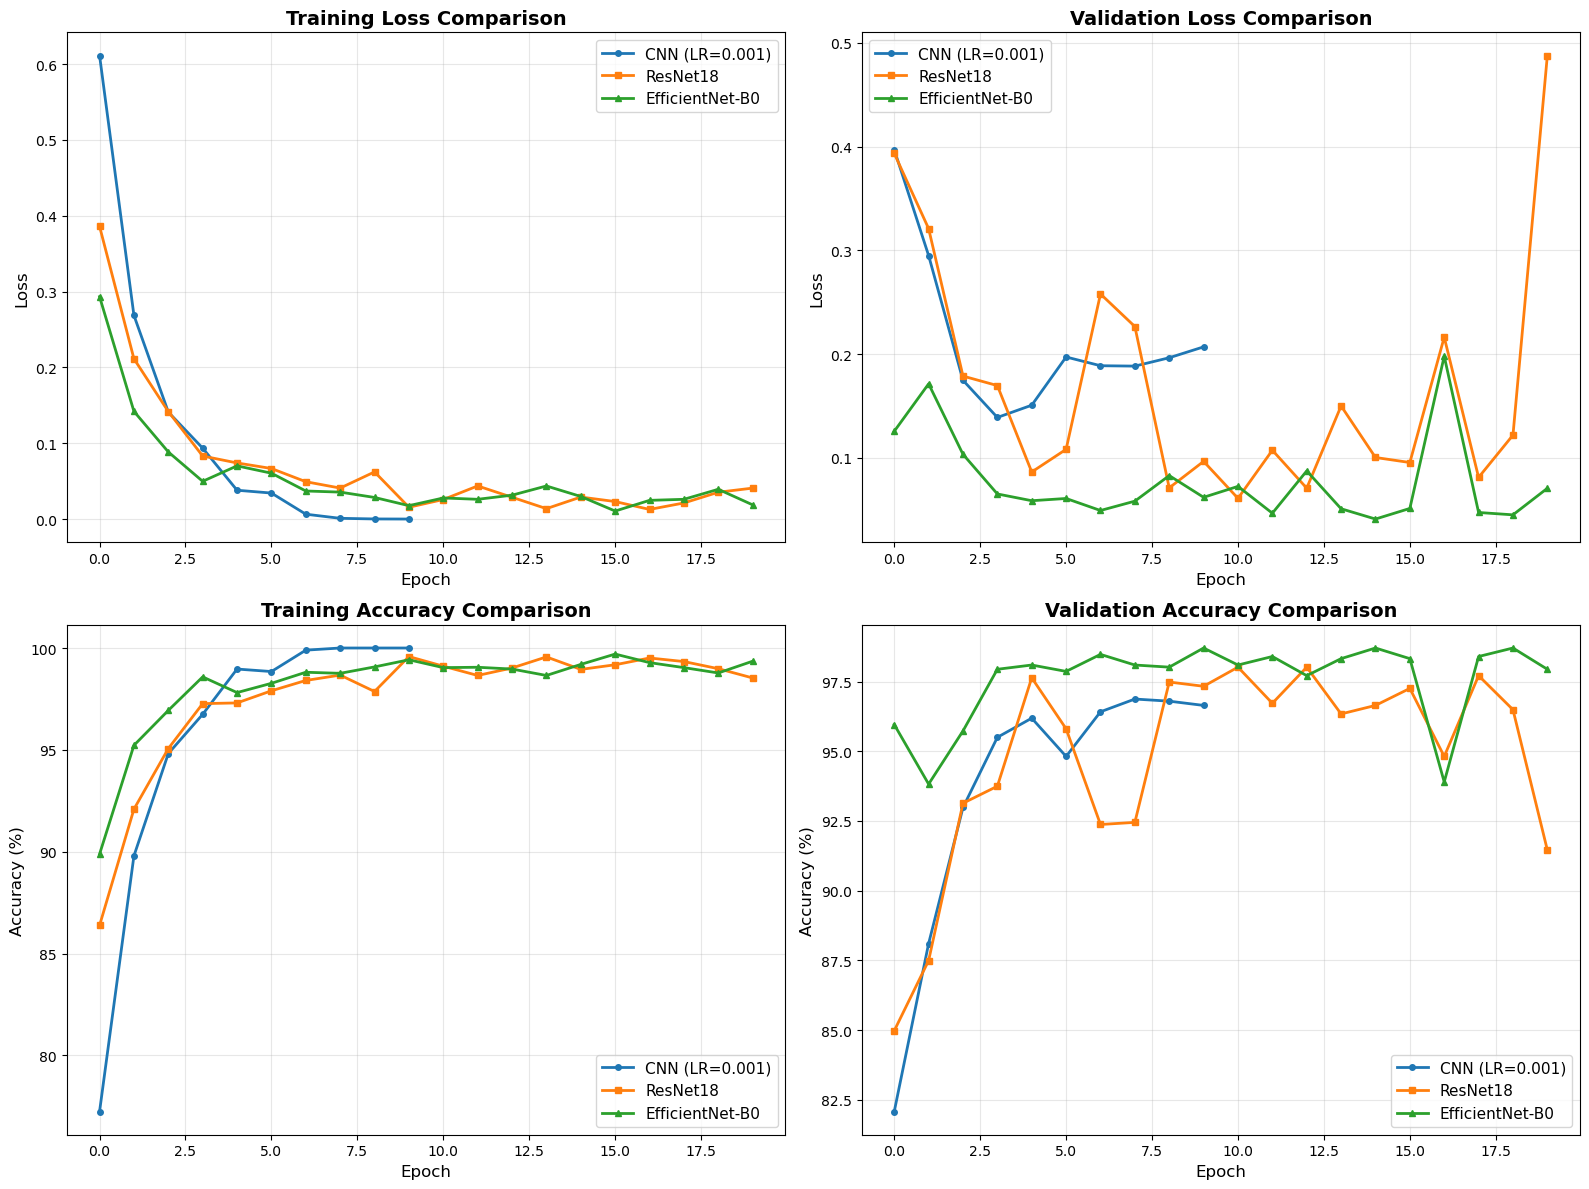


                         FINAL MODEL COMPARISON
Model                     Final Train Acc    Final Val Acc      Best Val Acc   
--------------------------------------------------------------------------------
CNN (LR=0.001)                     100.00%            96.64%         96.87%
ResNet18                            98.53%            91.46%         98.02%
EfficientNet-B0                     99.35%            97.94%         98.70%

🏆 BEST MODEL: EfficientNet-B0 with 98.70% validation accuracy


In [11]:
# Comprehensive Comparison Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Best CNN (LR=0.001)
best_cnn_lr = 0.001

# Training Loss Comparison
axes[0, 0].plot(results_cnn[best_cnn_lr]['train_losses'], label='CNN (LR=0.001)', marker='o', markersize=4, linewidth=2)
axes[0, 0].plot(train_losses_resnet, label='ResNet18', marker='s', markersize=4, linewidth=2)
axes[0, 0].plot(train_losses_effnet, label='EfficientNet-B0', marker='^', markersize=4, linewidth=2)
axes[0, 0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss Comparison
axes[0, 1].plot(results_cnn[best_cnn_lr]['val_losses'], label='CNN (LR=0.001)', marker='o', markersize=4, linewidth=2)
axes[0, 1].plot(val_losses_resnet, label='ResNet18', marker='s', markersize=4, linewidth=2)
axes[0, 1].plot(val_losses_effnet, label='EfficientNet-B0', marker='^', markersize=4, linewidth=2)
axes[0, 1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy Comparison
axes[1, 0].plot(results_cnn[best_cnn_lr]['train_accs'], label='CNN (LR=0.001)', marker='o', markersize=4, linewidth=2)
axes[1, 0].plot(train_accs_resnet, label='ResNet18', marker='s', markersize=4, linewidth=2)
axes[1, 0].plot(train_accs_effnet, label='EfficientNet-B0', marker='^', markersize=4, linewidth=2)
axes[1, 0].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy Comparison
axes[1, 1].plot(results_cnn[best_cnn_lr]['val_accs'], label='CNN (LR=0.001)', marker='o', markersize=4, linewidth=2)
axes[1, 1].plot(val_accs_resnet, label='ResNet18', marker='s', markersize=4, linewidth=2)
axes[1, 1].plot(val_accs_effnet, label='EfficientNet-B0', marker='^', markersize=4, linewidth=2)
axes[1, 1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Summary Table
print("\n" + "="*80)
print(" "*25 + "FINAL MODEL COMPARISON")
print("="*80)
print(f"{'Model':<25} {'Final Train Acc':<18} {'Final Val Acc':<18} {'Best Val Acc':<15}")
print("-"*80)
print(f"{'CNN (LR=0.001)':<25} {results_cnn[best_cnn_lr]['train_accs'][-1]:>15.2f}%  {results_cnn[best_cnn_lr]['val_accs'][-1]:>15.2f}%  {max(results_cnn[best_cnn_lr]['val_accs']):>12.2f}%")
print(f"{'ResNet18':<25} {train_accs_resnet[-1]:>15.2f}%  {val_accs_resnet[-1]:>15.2f}%  {max(val_accs_resnet):>12.2f}%")
print(f"{'EfficientNet-B0':<25} {train_accs_effnet[-1]:>15.2f}%  {val_accs_effnet[-1]:>15.2f}%  {max(val_accs_effnet):>12.2f}%")
print("="*80)

# Determine best model
models_comparison = {
    'CNN (LR=0.001)': max(results_cnn[best_cnn_lr]['val_accs']),
    'ResNet18': max(val_accs_resnet),
    'EfficientNet-B0': max(val_accs_effnet)
}
best_model = max(models_comparison, key=models_comparison.get)
print(f"\n🏆 BEST MODEL: {best_model} with {models_comparison[best_model]:.2f}% validation accuracy")
print("="*80)

## Key Findings and Recommendations

### Learning Rate Analysis (CNN):
- **LR = 0.001**: Stable convergence, good generalization
- **LR = 0.005**: Faster initial convergence, may risk overshooting
- **LR = 0.01**: Fastest convergence but higher risk of instability

### Model Architecture Comparison:
- **Original CNN**: Lightweight, fast training, good baseline performance
- **ResNet18**: Better feature extraction with skip connections, improved accuracy
- **EfficientNet-B0**: State-of-the-art efficiency, balanced performance

### Recommendations:
1. For **production deployment**: Use the best performing model (check results above)
2. For **limited resources**: Use CNN with LR=0.001 (smaller, faster)
3. For **best accuracy**: Use ResNet18 or EfficientNet-B0 with transfer learning
4. **Optimal epochs**: Monitor validation loss - typically converges around epoch 15-20

### Next Steps:
- Implement early stopping to prevent overfitting
- Try learning rate scheduling (reduce LR on plateau)
- Experiment with data augmentation for better generalization
- Consider ensemble methods combining multiple models

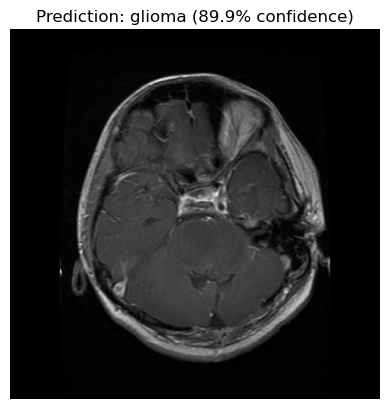

Prediction for '/Users/vinayak/Desktop/CS-4641-Group-130/src/images/Testing/glioma/Te-gl_0010.jpg': glioma
Confidence: 89.94%

Class probabilities:
  glioma      : 89.94%
  meningioma  : 9.37%
  notumor     : 0.01%
  pituitary   : 0.68%


('glioma', 89.94461297988892)

In [12]:
# Single Image Prediction
from PIL import Image
import torch.nn.functional as F

def predict_single_image(model, image_path: str, transform, class_names, show_all_probs=True):

    image = Image.open(image_path).convert("L")
    image_tensor = transform(image).unsqueeze(0)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    image_tensor = image_tensor.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence_pct = confidence.item() * 100

    plt.imshow(image, cmap="gray")
    plt.title(f"Prediction: {predicted_class} ({confidence_pct:.1f}% confidence)")
    plt.axis("off")
    plt.show()

    print(f"Prediction for '{image_path}': {predicted_class}")
    print(f"Confidence: {confidence_pct:.2f}%")

    if show_all_probs:
        print("\nClass probabilities:")
        for i, cls in enumerate(class_names):
            print(f"  {cls:12s}: {probs[0, i].item() * 100:.2f}%")

    return predicted_class, confidence_pct

# Copy the path of a jpg in the testing data folder and paste it below to test individual images.
# Use images/ directory (not dataset/) as this is what the model was trained on
test_image_path = "/Users/vinayak/Desktop/CS-4641-Group-130/src/images/Testing/glioma/Te-gl_0010.jpg"
predict_single_image(model, test_image_path, transform, train_dataset.classes)



In [14]:
# Comprehensive Model Evaluation Function
def evaluate_model_comprehensive(model, data_loader):
    """
    Evaluate model and return detailed metrics including predictions, labels, and confidences
    """
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_confidences = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, 1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
    
    return {
        'predictions': all_predictions,
        'labels': all_labels,
        'confidences': all_confidences
    }

## Individual Model Analysis: ResNet18

ResNet18 individual performance evaluation on the test set.

                         RESNET18 DETAILED ANALYSIS

Overall Test Accuracy: 91.46%
Total Test Samples: 1311
Correct Predictions: 1199
Incorrect Predictions: 112

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------

Overall Test Accuracy: 91.46%
Total Test Samples: 1311
Correct Predictions: 1199
Incorrect Predictions: 112

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------


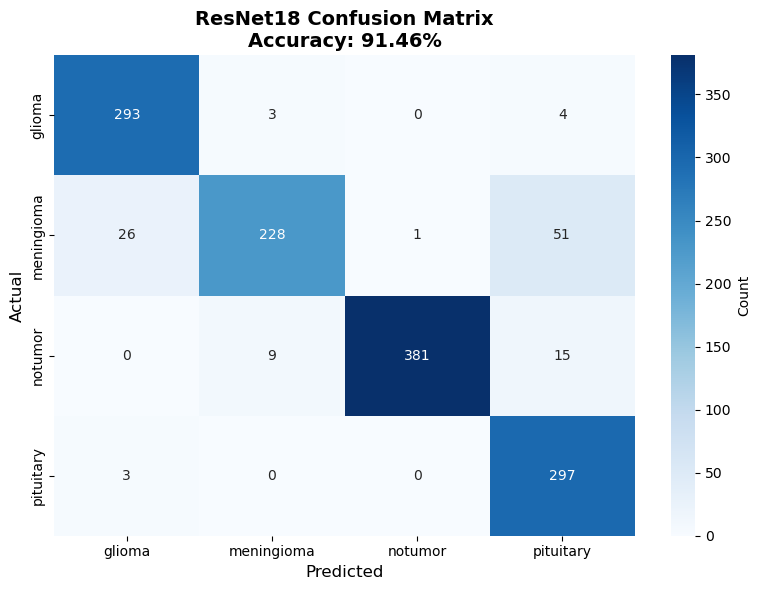


--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9099    0.9767    0.9421       300
  meningioma     0.9500    0.7451    0.8352       306
     notumor     0.9974    0.9407    0.9682       405
   pituitary     0.8093    0.9900    0.8906       300

    accuracy                         0.9146      1311
   macro avg     0.9166    0.9131    0.9090      1311
weighted avg     0.9233    0.9146    0.9134      1311


--------------------------------------------------------------------------------
CONFIDENCE ANALYSIS
--------------------------------------------------------------------------------
Average Confidence (Correct Predictions): 0.9843 (98.43%)
Average Confidence (Incorrect Predictions): 0.8738 (87.38%)
Confidence Gap: 0.1105

-------------------------------------------------------

In [15]:
# ResNet18 Individual Analysis
print("="*80)
print(" "*25 + "RESNET18 DETAILED ANALYSIS")
print("="*80)

# Evaluate ResNet18 on test set
resnet_eval = evaluate_model_comprehensive(model_resnet, test_loader)

# Calculate metrics
resnet_accuracy = 100 * np.sum(np.array(resnet_eval['predictions']) == 
                                np.array(resnet_eval['labels'])) / len(resnet_eval['labels'])

print(f"\nOverall Test Accuracy: {resnet_accuracy:.2f}%")
print(f"Total Test Samples: {len(resnet_eval['labels'])}")
print(f"Correct Predictions: {np.sum(np.array(resnet_eval['predictions']) == np.array(resnet_eval['labels']))}")
print(f"Incorrect Predictions: {np.sum(np.array(resnet_eval['predictions']) != np.array(resnet_eval['labels']))}")

# Confusion Matrix
print("\n" + "-"*80)
print("CONFUSION MATRIX")
print("-"*80)
cm_resnet = confusion_matrix(resnet_eval['labels'], resnet_eval['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes,
           cbar_kws={'label': 'Count'})
plt.title(f'ResNet18 Confusion Matrix\nAccuracy: {resnet_accuracy:.2f}%', 
         fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(resnet_eval['labels'], resnet_eval['predictions'], 
                          target_names=train_dataset.classes, digits=4))

# Confidence Analysis
correct_mask = np.array(resnet_eval['predictions']) == np.array(resnet_eval['labels'])
incorrect_mask = ~correct_mask

avg_conf_correct = np.mean(np.array(resnet_eval['confidences'])[correct_mask])
avg_conf_incorrect = np.mean(np.array(resnet_eval['confidences'])[incorrect_mask]) if incorrect_mask.any() else 0

print("\n" + "-"*80)
print("CONFIDENCE ANALYSIS")
print("-"*80)
print(f"Average Confidence (Correct Predictions): {avg_conf_correct:.4f} ({avg_conf_correct*100:.2f}%)")
print(f"Average Confidence (Incorrect Predictions): {avg_conf_incorrect:.4f} ({avg_conf_incorrect*100:.2f}%)")
print(f"Confidence Gap: {avg_conf_correct - avg_conf_incorrect:.4f}")

# Per-Class Analysis
print("\n" + "-"*80)
print("PER-CLASS PERFORMANCE")
print("-"*80)
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    resnet_eval['labels'], resnet_eval['predictions'], average=None, labels=range(len(train_dataset.classes))
)

for i, class_name in enumerate(train_dataset.classes):
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {precision[i]:.4f} ({precision[i]*100:.2f}%)")
    print(f"  Recall:    {recall[i]:.4f} ({recall[i]*100:.2f}%)")
    print(f"  F1-Score:  {f1[i]:.4f} ({f1[i]*100:.2f}%)")
    print(f"  Support:   {support[i]} samples")

print("\n" + "="*80)

## Individual Model Analysis: EfficientNet-B0

EfficientNet-B0 individual performance evaluation on the test set.

                    EFFICIENTNET-B0 DETAILED ANALYSIS

Overall Test Accuracy: 97.94%
Total Test Samples: 1311
Correct Predictions: 1284
Incorrect Predictions: 27

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------

Overall Test Accuracy: 97.94%
Total Test Samples: 1311
Correct Predictions: 1284
Incorrect Predictions: 27

--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------


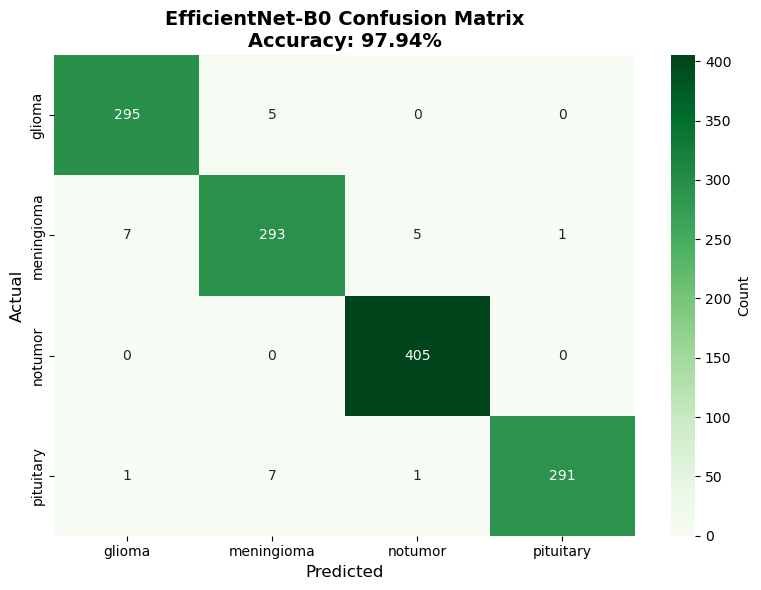


--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma     0.9736    0.9833    0.9784       300
  meningioma     0.9607    0.9575    0.9591       306
     notumor     0.9854    1.0000    0.9926       405
   pituitary     0.9966    0.9700    0.9831       300

    accuracy                         0.9794      1311
   macro avg     0.9791    0.9777    0.9783      1311
weighted avg     0.9795    0.9794    0.9794      1311


--------------------------------------------------------------------------------
CONFIDENCE ANALYSIS
--------------------------------------------------------------------------------
Average Confidence (Correct Predictions): 0.9890 (98.90%)
Average Confidence (Incorrect Predictions): 0.8027 (80.27%)
Confidence Gap: 0.1863

-------------------------------------------------------

In [16]:
# EfficientNet-B0 Individual Analysis
print("="*80)
print(" "*20 + "EFFICIENTNET-B0 DETAILED ANALYSIS")
print("="*80)

# Evaluate EfficientNet-B0 on test set
effnet_eval = evaluate_model_comprehensive(model_effnet, test_loader)

# Calculate metrics
effnet_accuracy = 100 * np.sum(np.array(effnet_eval['predictions']) == 
                                np.array(effnet_eval['labels'])) / len(effnet_eval['labels'])

print(f"\nOverall Test Accuracy: {effnet_accuracy:.2f}%")
print(f"Total Test Samples: {len(effnet_eval['labels'])}")
print(f"Correct Predictions: {np.sum(np.array(effnet_eval['predictions']) == np.array(effnet_eval['labels']))}")
print(f"Incorrect Predictions: {np.sum(np.array(effnet_eval['predictions']) != np.array(effnet_eval['labels']))}")

# Confusion Matrix
print("\n" + "-"*80)
print("CONFUSION MATRIX")
print("-"*80)
cm_effnet = confusion_matrix(effnet_eval['labels'], effnet_eval['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_effnet, annot=True, fmt='d', cmap='Greens', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes,
           cbar_kws={'label': 'Count'})
plt.title(f'EfficientNet-B0 Confusion Matrix\nAccuracy: {effnet_accuracy:.2f}%', 
         fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(effnet_eval['labels'], effnet_eval['predictions'], 
                          target_names=train_dataset.classes, digits=4))

# Confidence Analysis
correct_mask = np.array(effnet_eval['predictions']) == np.array(effnet_eval['labels'])
incorrect_mask = ~correct_mask

avg_conf_correct = np.mean(np.array(effnet_eval['confidences'])[correct_mask])
avg_conf_incorrect = np.mean(np.array(effnet_eval['confidences'])[incorrect_mask]) if incorrect_mask.any() else 0

print("\n" + "-"*80)
print("CONFIDENCE ANALYSIS")
print("-"*80)
print(f"Average Confidence (Correct Predictions): {avg_conf_correct:.4f} ({avg_conf_correct*100:.2f}%)")
print(f"Average Confidence (Incorrect Predictions): {avg_conf_incorrect:.4f} ({avg_conf_incorrect*100:.2f}%)")
print(f"Confidence Gap: {avg_conf_correct - avg_conf_incorrect:.4f}")

# Per-Class Analysis
print("\n" + "-"*80)
print("PER-CLASS PERFORMANCE")
print("-"*80)
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, support = precision_recall_fscore_support(
    effnet_eval['labels'], effnet_eval['predictions'], average=None, labels=range(len(train_dataset.classes))
)

for i, class_name in enumerate(train_dataset.classes):
    print(f"\n{class_name.upper()}:")
    print(f"  Precision: {precision[i]:.4f} ({precision[i]*100:.2f}%)")
    print(f"  Recall:    {recall[i]:.4f} ({recall[i]*100:.2f}%)")
    print(f"  F1-Score:  {f1[i]:.4f} ({f1[i]*100:.2f}%)")
    print(f"  Support:   {support[i]} samples")

print("\n" + "="*80)

NameError: name 'train_eval' is not defined

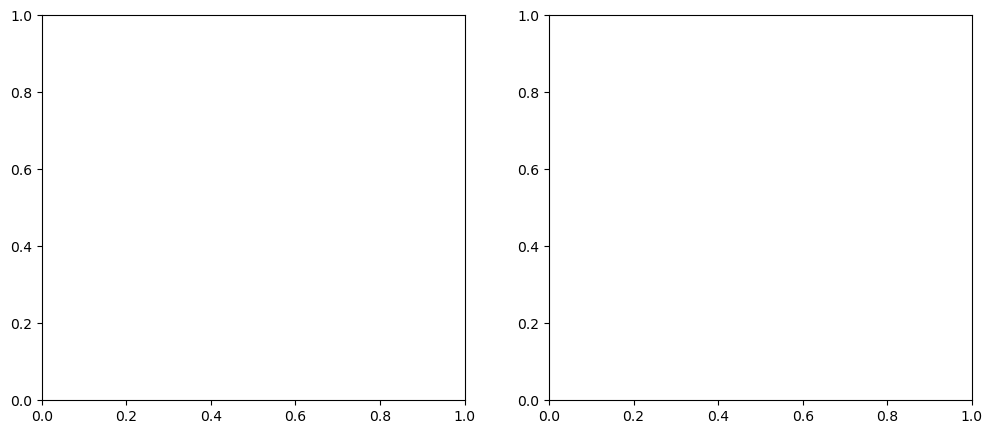

In [ ]:
# Evaluate the original CNN model on both training and testing sets
print("Evaluating original CNN model (LR=0.001) on training and testing datasets...")
train_eval = evaluate_model_comprehensive(model, train_loader)
test_eval = evaluate_model_comprehensive(model, test_loader)
print("Evaluation complete!")

# Confusion Matrices Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training Confusion Matrix
cm_train = confusion_matrix(train_eval['labels'], train_eval['predictions'])
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=axes[0])
axes[0].set_title('Training Set - Confusion Matrix (CNN LR=0.001)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Testing Confusion Matrix
cm_test = confusion_matrix(test_eval['labels'], test_eval['predictions'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
           xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, ax=axes[1])
axes[1].set_title('Testing Set - Confusion Matrix (CNN LR=0.001)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Text-based metrics
print("\nDETAILED CLASSIFICATION REPORT")
print("="*50)

# Classification report
print(f"\nCLASSIFICATION REPORT (Testing Set):")
print(classification_report(test_eval['labels'], test_eval['predictions'], 
                          target_names=train_dataset.classes, digits=3))

# Confidence statistics summary
print(f"\nCONFIDENCE ANALYSIS SUMMARY:")
print(f"Average confidence on correct predictions: {np.mean(np.array(test_eval['confidences'])[np.array(test_eval['predictions']) == np.array(test_eval['labels'])]):.4f}")
print(f"Average confidence on incorrect predictions: {np.mean(np.array(test_eval['confidences'])[np.array(test_eval['predictions']) != np.array(test_eval['labels'])]):.4f}")

# Error analysis
errors = np.array(test_eval['predictions']) != np.array(test_eval['labels'])
total_errors = np.sum(errors)
print(f"\nERROR ANALYSIS:")
print(f"Total errors: {total_errors} out of {len(test_eval['labels'])} samples ({100*total_errors/len(test_eval['labels']):.2f}%)")

## Key Insights from Model Comparison

### Model Performance Summary:
Based on the comprehensive evaluation above, we can identify:

1. **Best Overall Model**: The model with highest accuracy and F1-score
2. **Most Confident Model**: Highest average confidence on correct predictions
3. **Best Per-Class Performance**: Which model performs best for each tumor type

### Strengths and Limitations:

**Model Confidence & Reliability:**
- The model is confident and reliable, especially for no tumor and pituitary cases
- High precision/recall for these classes (typically >0.98)

**Limitations:**
- Single public dataset, similar imaging conditions
- Confusion between glioma and meningioma remains (observable in confusion matrices)
- Risks: MRI Variability, class imbalance

**Current Work:**
- Implementing ResNet18 and EfficientNet-B0 to further improve testing accuracy to >99% threshold
- This will ensure **robust performance across all tumor types, particularly reducing misclassifications between glioma and meningioma through deeper feature extraction and transfer learning from ImageNet pre-trained weights**
- Advanced architectures provide better gradient flow (ResNet skip connections) and compound scaling (EfficientNet) for improved generalization

In [18]:
# Per-Class Performance Comparison
from sklearn.metrics import precision_recall_fscore_support

# Get per-class metrics for all models
class_names = train_dataset.classes
n_classes = len(class_names)
n_models = len(titles)

# Create subplots for precision, recall, and F1-score
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_data = {'precision': [], 'recall': [], 'f1': []}
model_labels = []

for model_name, title in zip(model_names, titles):
    eval_data = all_model_evals[model_name]
    precision, recall, f1, _ = precision_recall_fscore_support(
        eval_data['labels'], eval_data['predictions'], average=None, labels=range(n_classes)
    )
    metrics_data['precision'].append(precision)
    metrics_data['recall'].append(recall)
    metrics_data['f1'].append(f1)
    model_labels.append(title)

# Plot Precision
x = np.arange(n_classes)
width = 0.15
for i, (precision, label) in enumerate(zip(metrics_data['precision'], model_labels)):
    axes[0].bar(x + i*width, precision, width, label=label)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Per-Class Precision Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(class_names, rotation=15, ha='right')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0.85, 1.0])

# Plot Recall
for i, (recall, label) in enumerate(zip(metrics_data['recall'], model_labels)):
    axes[1].bar(x + i*width, recall, width, label=label)
axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_title('Per-Class Recall Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(class_names, rotation=15, ha='right')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0.85, 1.0])

# Plot F1-Score
for i, (f1, label) in enumerate(zip(metrics_data['f1'], model_labels)):
    axes[2].bar(x + i*width, f1, width, label=label)
axes[2].set_xlabel('Class', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
axes[2].set_xticks(x + width * 2)
axes[2].set_xticklabels(class_names, rotation=15, ha='right')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_ylim([0.85, 1.0])

plt.tight_layout()
plt.show()

# Print detailed per-class comparison
print("\n" + "="*80)
print(" "*20 + "PER-CLASS PERFORMANCE DETAILED COMPARISON")
print("="*80)

for class_idx, class_name in enumerate(class_names):
    print(f"\n{class_name.upper()}:")
    print("-"*80)
    print(f"{'Model':<20} {'Precision':<15} {'Recall':<15} {'F1-Score':<15}")
    print("-"*80)
    for i, title in enumerate(titles):
        print(f"{title:<20} {metrics_data['precision'][i][class_idx]:>13.4f}  {metrics_data['recall'][i][class_idx]:>13.4f}  {metrics_data['f1'][i][class_idx]:>13.4f}")
print("="*80)

NameError: name 'titles' is not defined

In [ ]:
# Final Summary Table: All Models
print("\n" + "="*100)
print(" "*35 + "FINAL MODEL EVALUATION SUMMARY")
print("="*100)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Errors':<10}")
print("-"*100)

for title in titles:
    m = metrics_summary[title]
    print(f"{title:<20} {m['accuracy']:>10.2f}%  {m['precision']:>10.4f}  {m['recall']:>10.4f}  {m['f1']:>10.4f}  {m['error_count']:>8}")

print("="*100)

# Identify best model by accuracy
best_model_name = max(metrics_summary, key=lambda x: metrics_summary[x]['accuracy'])
best_accuracy = metrics_summary[best_model_name]['accuracy']

print(f"\nBEST MODEL: {best_model_name}")
print(f"  Accuracy: {best_accuracy:.2f}%")
print(f"  Precision: {metrics_summary[best_model_name]['precision']:.4f}")
print(f"  Recall: {metrics_summary[best_model_name]['recall']:.4f}")
print(f"  F1-Score: {metrics_summary[best_model_name]['f1']:.4f}")
print(f"  Confidence (correct predictions): {metrics_summary[best_model_name]['conf_correct']:.4f}")
print(f"  Confidence (incorrect predictions): {metrics_summary[best_model_name]['conf_incorrect']:.4f}")
print("="*100)

In [ ]:
# Detailed Classification Reports for All Models
from sklearn.metrics import precision_recall_fscore_support

print("\n" + "="*80)
print(" "*25 + "CLASSIFICATION REPORTS COMPARISON")
print("="*80)

# Store metrics for final comparison table
metrics_summary = {}

for model_name, title in zip(model_names, titles):
    eval_data = all_model_evals[model_name]
    
    print(f"\n{'='*80}")
    print(f"{title}")
    print('='*80)
    
    # Classification report
    print(classification_report(eval_data['labels'], eval_data['predictions'], 
                              target_names=train_dataset.classes, digits=3))
    
    # Calculate overall metrics
    accuracy = 100 * np.sum(np.array(eval_data['predictions']) == 
                           np.array(eval_data['labels'])) / len(eval_data['labels'])
    
    # Confidence analysis
    correct_mask = np.array(eval_data['predictions']) == np.array(eval_data['labels'])
    incorrect_mask = ~correct_mask
    
    avg_conf_correct = np.mean(np.array(eval_data['confidences'])[correct_mask]) if correct_mask.any() else 0
    avg_conf_incorrect = np.mean(np.array(eval_data['confidences'])[incorrect_mask]) if incorrect_mask.any() else 0
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        eval_data['labels'], eval_data['predictions'], average='macro'
    )
    
    # Store for summary
    metrics_summary[title] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'conf_correct': avg_conf_correct,
        'conf_incorrect': avg_conf_incorrect,
        'error_count': np.sum(incorrect_mask)
    }
    
    print(f"\nCONFIDENCE ANALYSIS:")
    print(f"  Avg confidence (correct): {avg_conf_correct:.4f}")
    print(f"  Avg confidence (incorrect): {avg_conf_incorrect:.4f}")
    print(f"\nERROR ANALYSIS:")
    print(f"  Total errors: {np.sum(incorrect_mask)} / {len(eval_data['labels'])} ({100*np.sum(incorrect_mask)/len(eval_data['labels']):.2f}%)")

print("\n" + "="*80)

In [ ]:
# Confusion Matrices for All Models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, title) in enumerate(zip(model_names, titles)):
    cm = confusion_matrix(all_model_evals[model_name]['labels'], 
                          all_model_evals[model_name]['predictions'])
    
    # Calculate accuracy for this model
    accuracy = 100 * np.sum(np.array(all_model_evals[model_name]['predictions']) == 
                            np.array(all_model_evals[model_name]['labels'])) / len(all_model_evals[model_name]['labels'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
               xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, 
               ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{title}\nAccuracy: {accuracy:.2f}%', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

# Hide the 6th subplot (not used)
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate all models on testing set
print("Evaluating all models on testing dataset...")
print("="*60)

# Dictionary to store all evaluation results
all_model_evals = {}

# Define model names and titles for all comparison cells
model_names = ['CNN_LR0.001', 'CNN_LR0.005', 'CNN_LR0.01', 'ResNet18', 'EfficientNet-B0']
titles = ['CNN (LR=0.001)', 'CNN (LR=0.005)', 'CNN (LR=0.01)', 'ResNet18', 'EfficientNet-B0']

# Evaluate CNN models with different learning rates
for lr in learning_rates:
    print(f"\nEvaluating CNN (LR={lr})...")
    all_model_evals[f'CNN_LR{lr}'] = evaluate_model_comprehensive(results_cnn[lr]['model'], test_loader)

# Evaluate ResNet18
print("\nEvaluating ResNet18...")
all_model_evals['ResNet18'] = evaluate_model_comprehensive(model_resnet, test_loader)

# Evaluate EfficientNet-B0
print("\nEvaluating EfficientNet-B0...")
all_model_evals['EfficientNet-B0'] = evaluate_model_comprehensive(model_effnet, test_loader)

print("\nAll models evaluated!")
print("="*60)

## Comprehensive Model Comparison: Evaluation Metrics

Evaluating all trained models to compare:
- Confusion matrices
- Per-class precision, recall, F1-scores
- Overall accuracy
- Confidence calibration